In [6]:
import os
import sys
from pathlib import Path

os.environ.setdefault("KERAS_BACKEND", "tensorflow")
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib")

PROJECT_ROOT = Path("/Users/yimingzang/Documents/Project/benchmark2")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import bayesflow as bf
pd.set_option("display.max_columns", 100)

In [7]:
from benchmark.examples.diffusion.config import MODELS, RESULT_DIR, TrainingConfig, ensure_dirs
from benchmark.examples.diffusion.dataset import wagenmakers
from benchmark.examples.diffusion.simulators import SIMULATORS
from benchmark.examples.diffusion.approximators.indirect import load_approximator, load_history
from benchmark.examples.diffusion.results.results import (
    attach_gold_standard,
    estimate_model_comparison,
    load_results,
    save_results,
)
from benchmark.examples.diffusion.results.summary_diagnostic import (
    add_summary_diagnostics,
    fit_references,
    load_diagnostic,
    load_references,
    save_diagnostic,
    save_references,
)
from benchmark.examples.diffusion.results.plots import (
    plot_logml_error_vs_rho,
    plot_pmp_error_vs_log_ambiguity,
    plot_pmp_error_vs_rho,
    plot_pmp_estimates_vs_distance,
)

ensure_dirs()


In [8]:
from tqdm.auto import tqdm as original_tqdm
import bayesflow.approximators.helpers.samplers as bf_samplers
import bayesflow.approximators.helpers.conditions as bf_conditions

def quiet_tqdm(*args, **kwargs):
    kwargs["disable"] = True
    return original_tqdm(*args, **kwargs)

bf_samplers.tqdm = quiet_tqdm
bf_conditions.tqdm = quiet_tqdm


## 1. Load trained NPE approximators


In [9]:
config = TrainingConfig(epochs=50, batch_size=64, num_batches=64, summary_multiplier=1)
summary_tag = config.summary_label
results_path = RESULT_DIR / f"npe_{summary_tag}_results_gold.csv"
references_path = RESULT_DIR / f"npe_{summary_tag}_references.pkl"
diagnostic_path = RESULT_DIR / f"npe_{summary_tag}_empirical_diagnostic.csv"

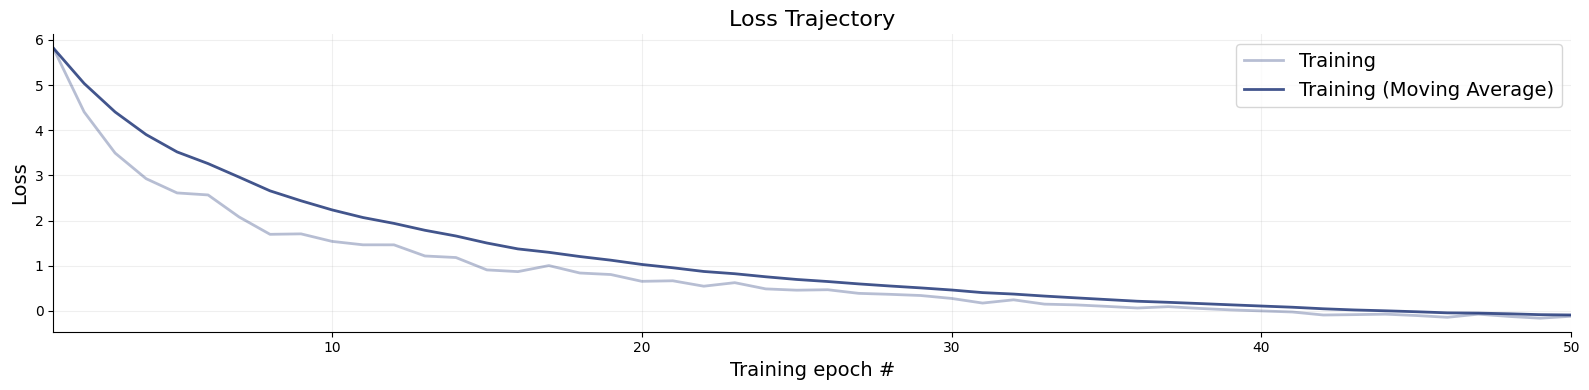

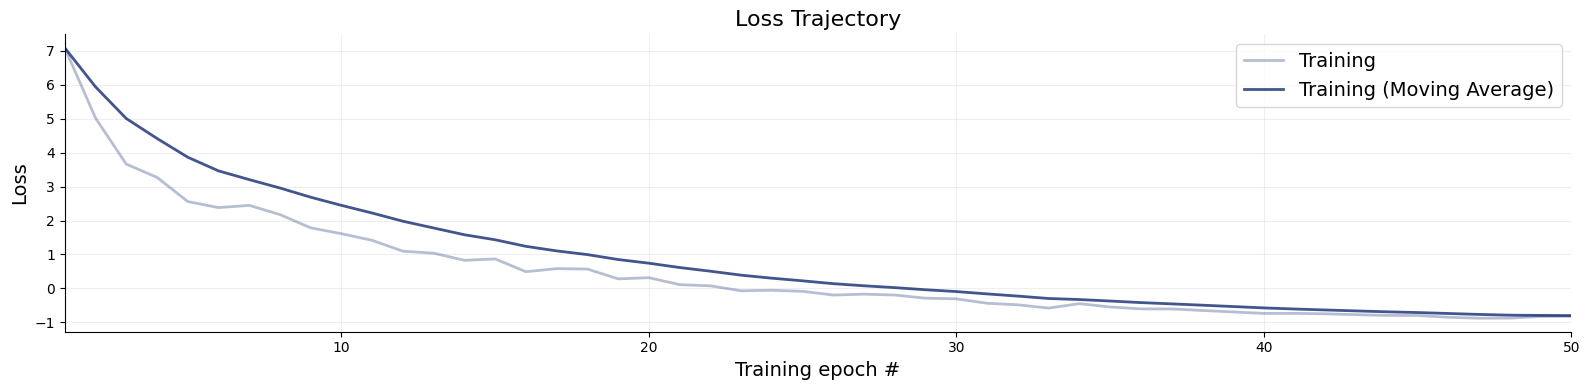

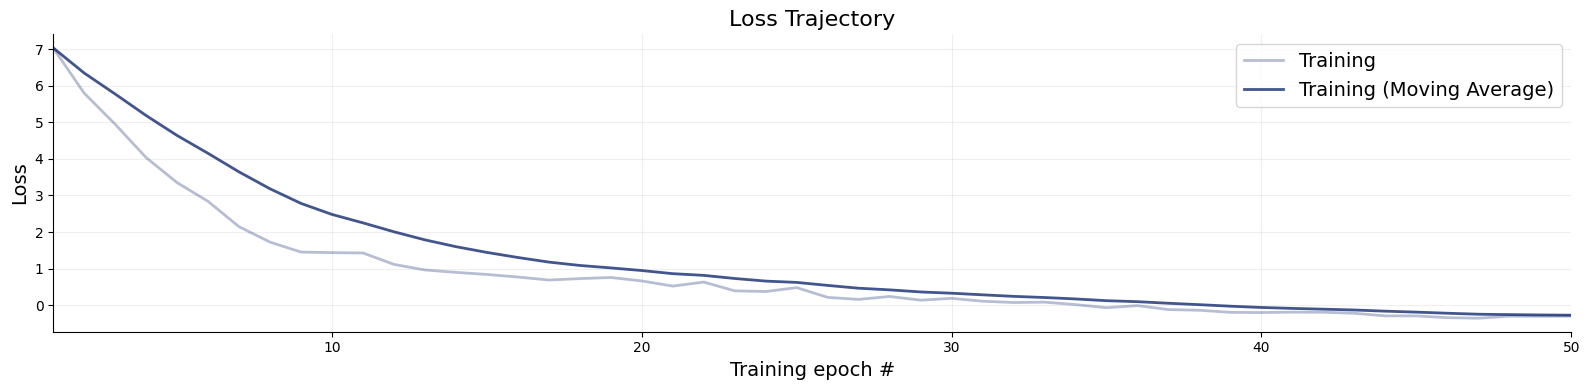

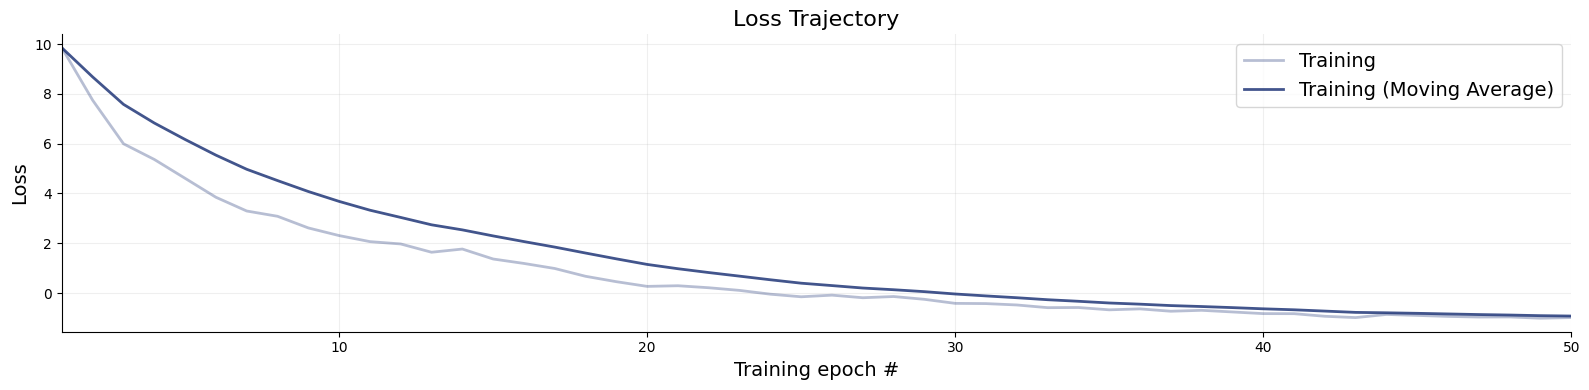

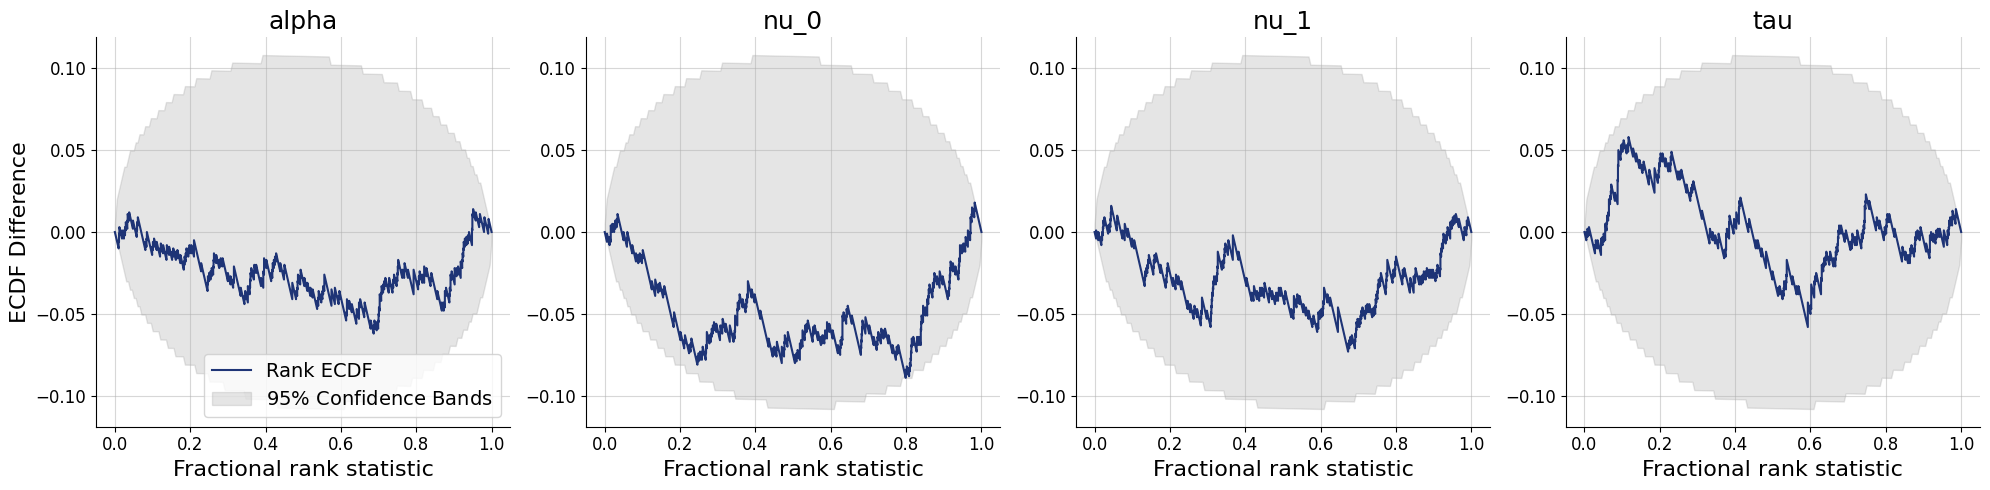

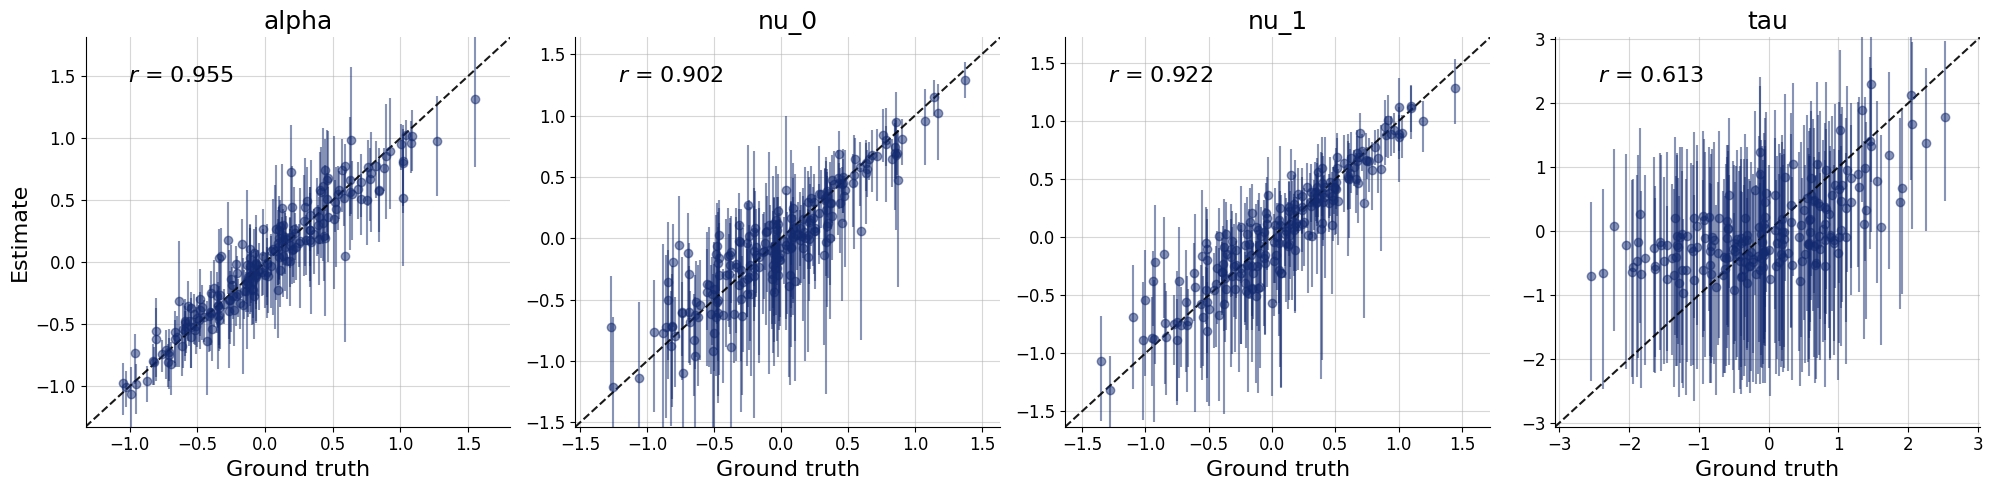

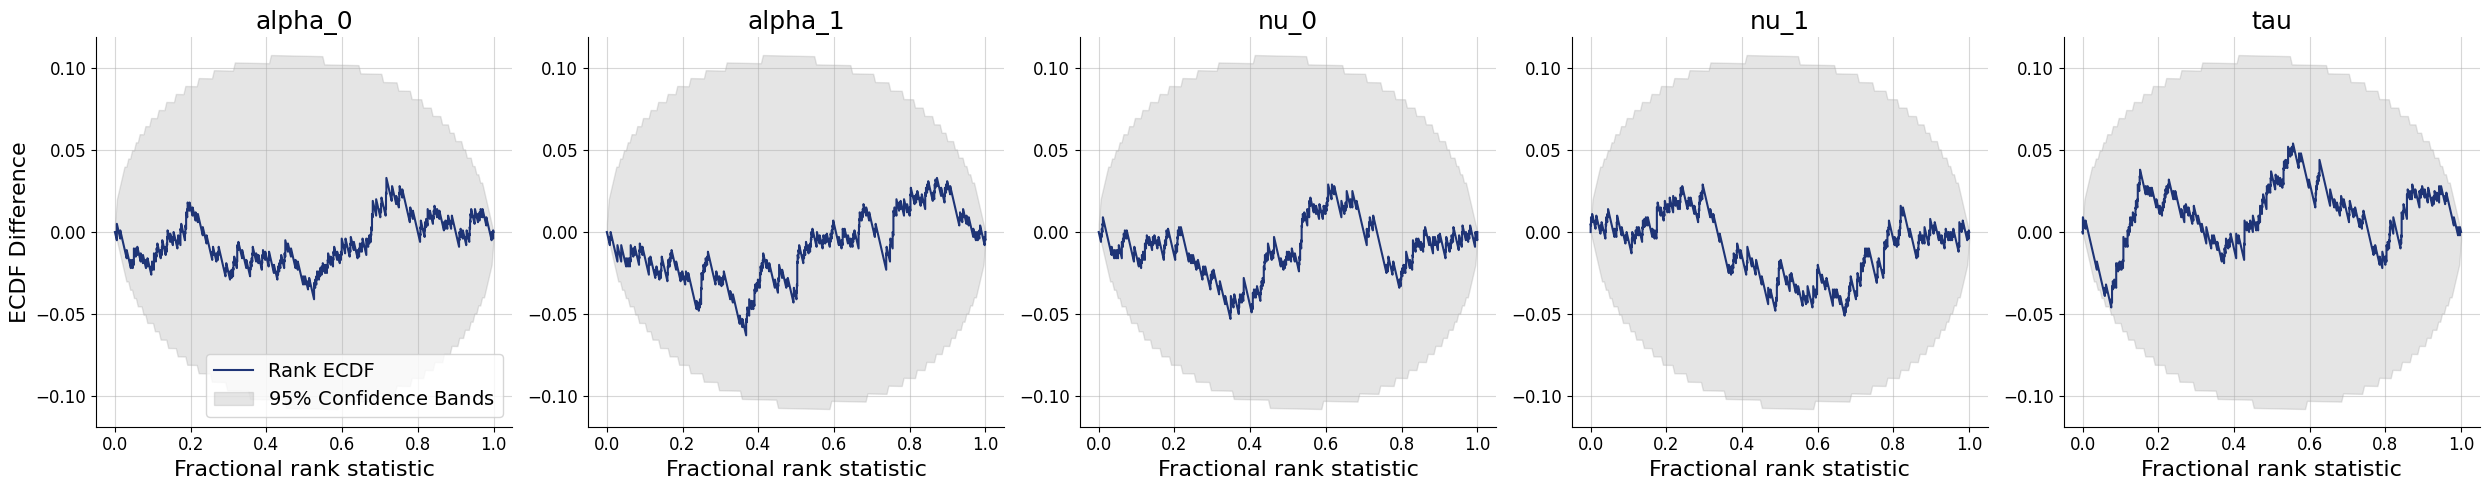

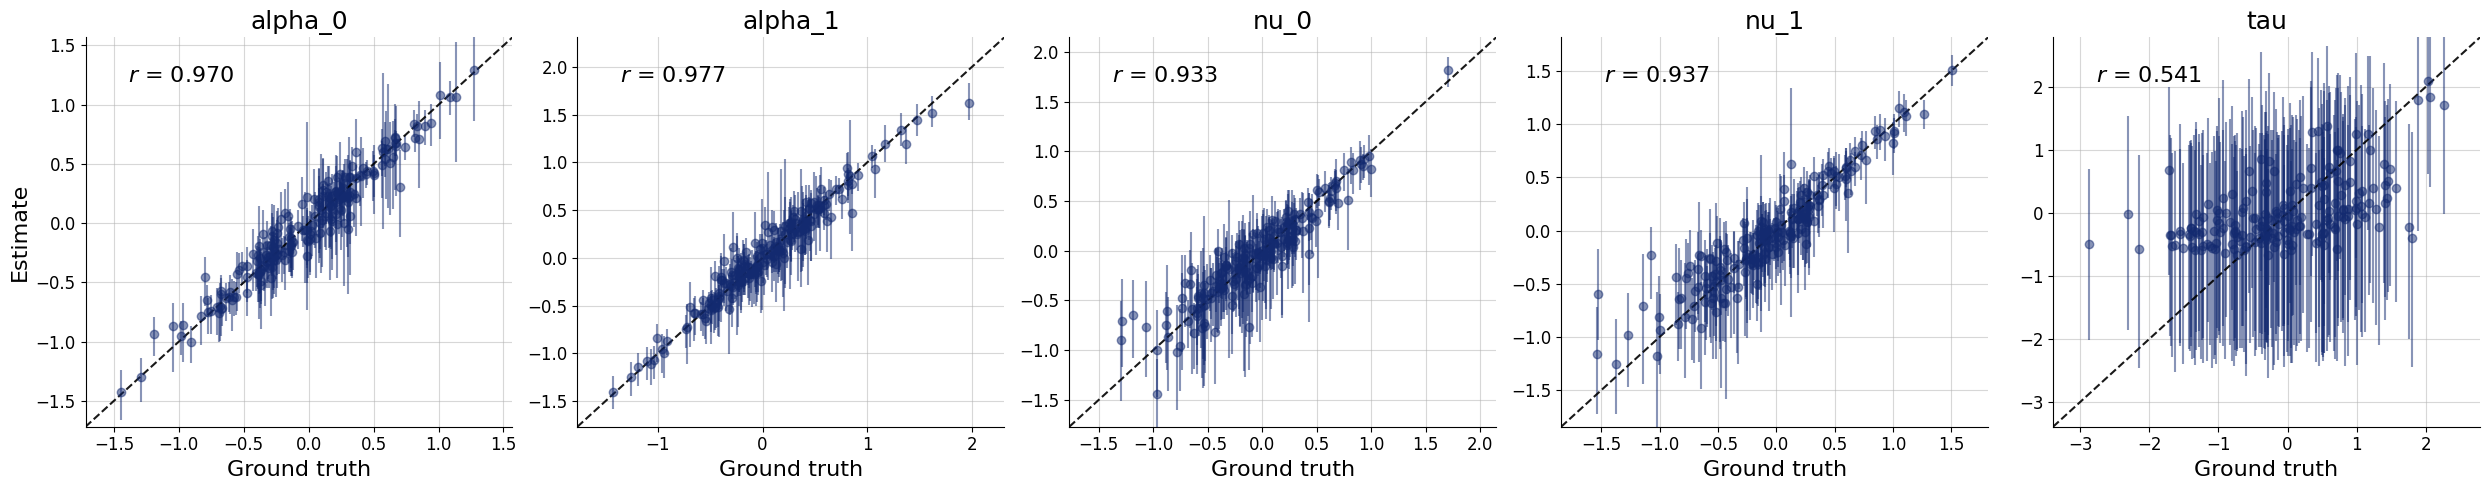

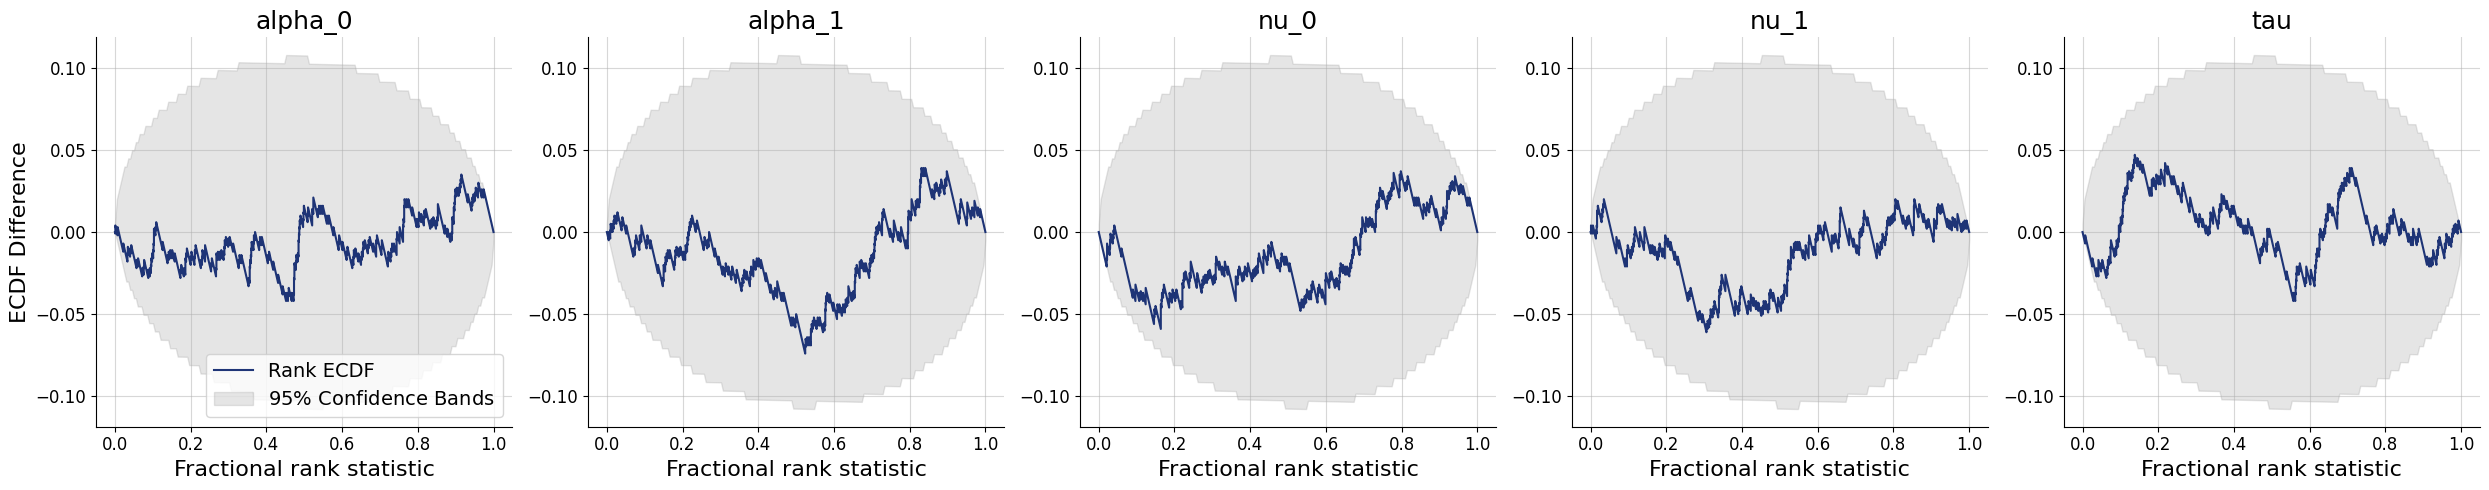

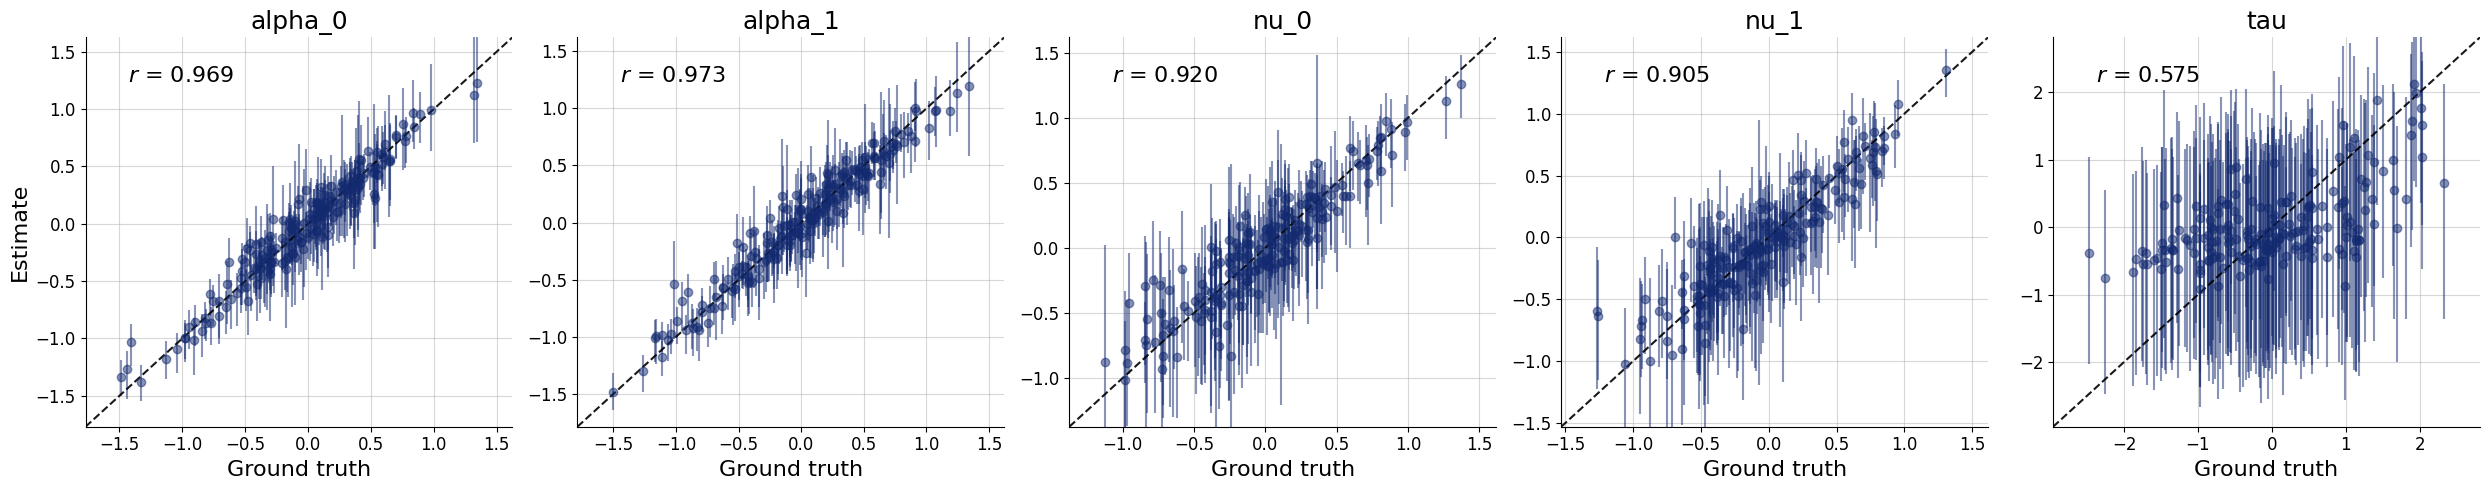

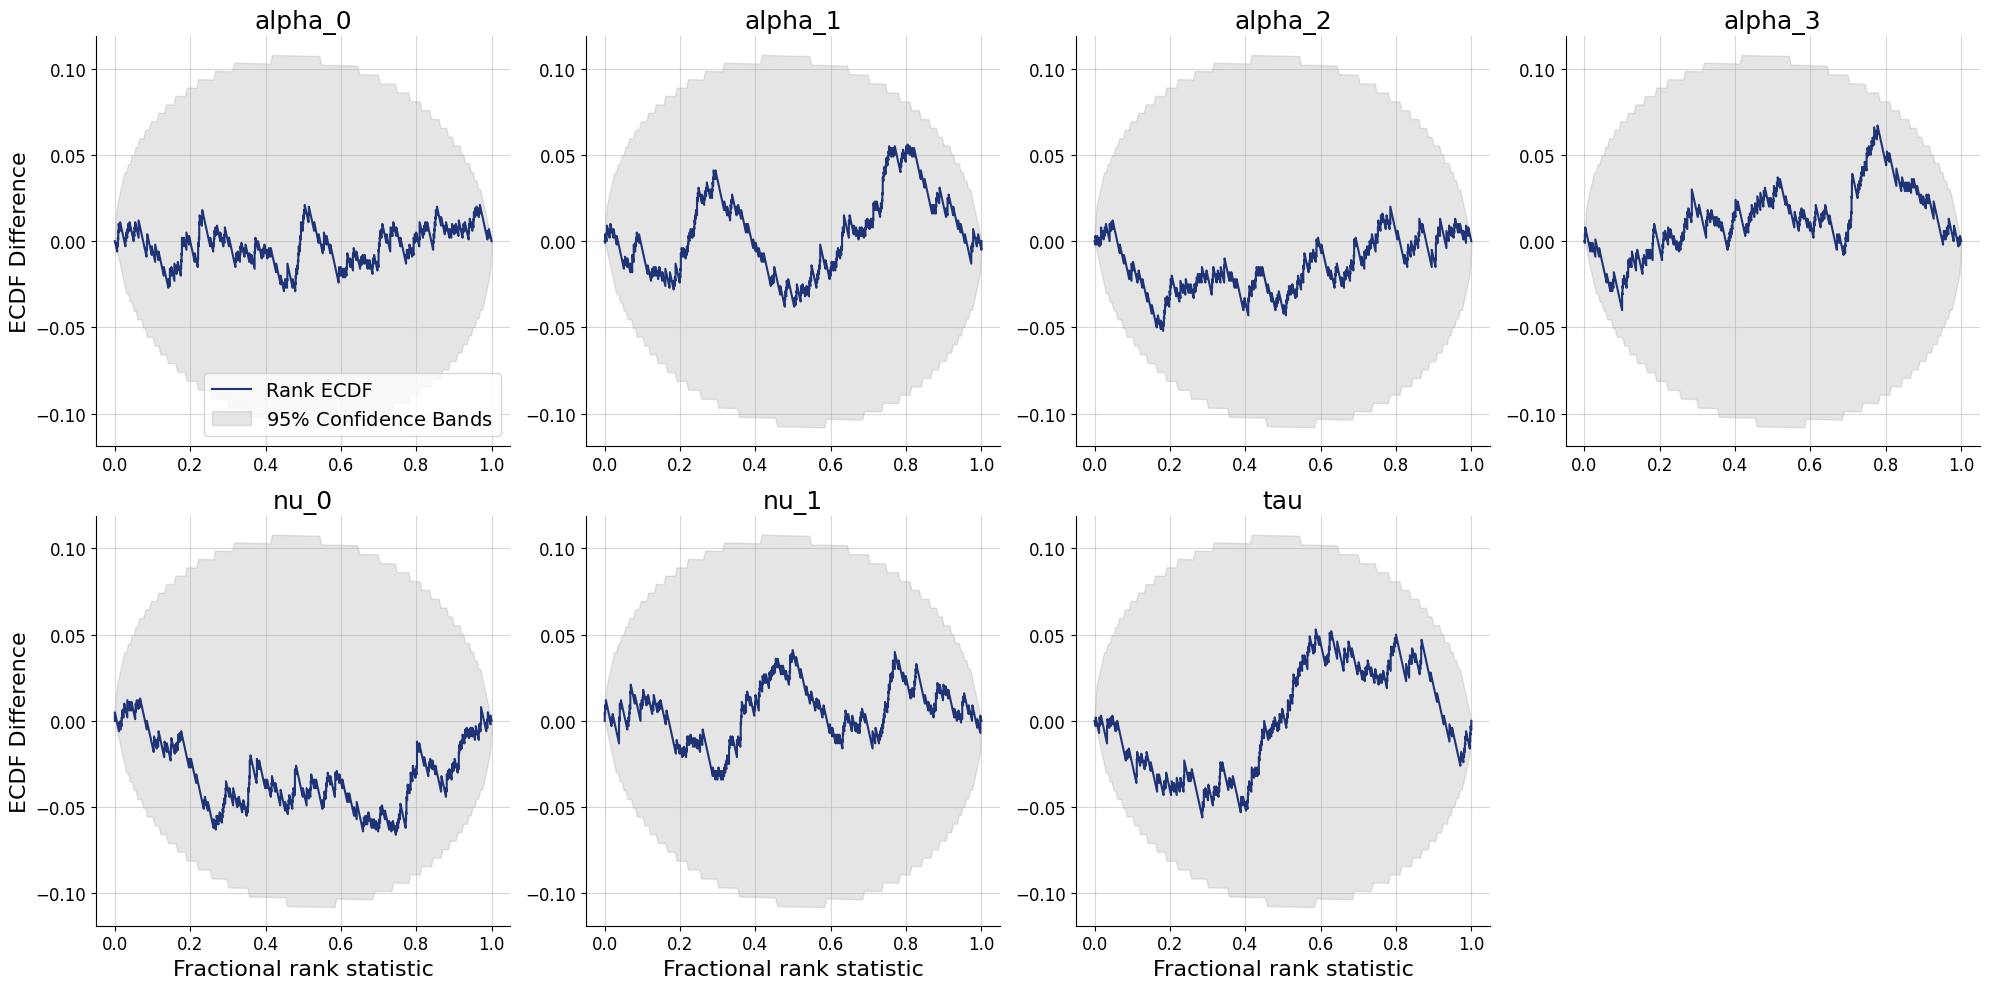

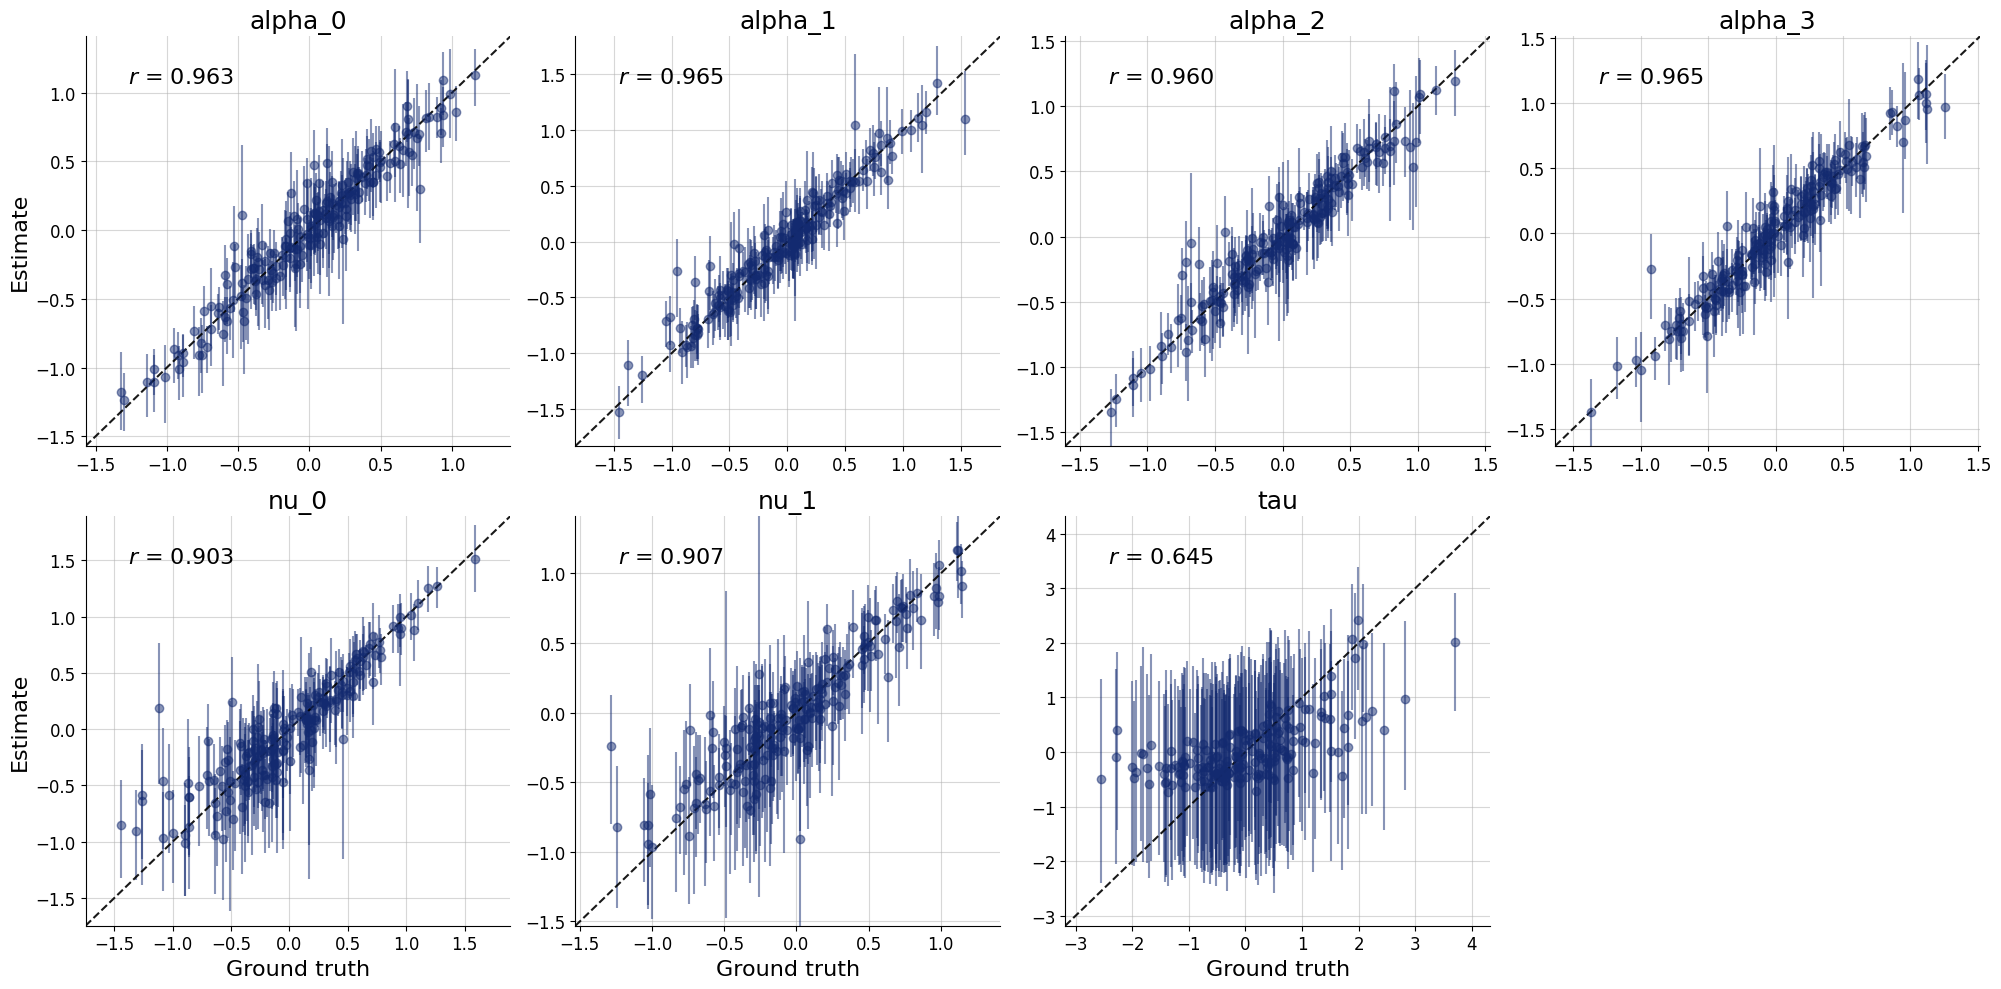

In [10]:
approximators = {model: load_approximator(model, config=config) for model in MODELS}
histories = {model: load_history(model, config=config) for model in MODELS}

for model in MODELS:
    bf.diagnostics.plots.loss(histories[model])

num_samples = 1000
for model in MODELS:
    val_sims = SIMULATORS[model].sample(200)
    post_draws = approximators[model].sample(conditions=val_sims, num_samples=num_samples)
    bf.diagnostics.plots.calibration_ecdf(post_draws, val_sims, difference=True)
    bf.diagnostics.plots.recovery(post_draws, val_sims)


## 2. Load empirical datasets

In [11]:
empirical = wagenmakers.df_array
ids = wagenmakers.ids

empirical.shape, ids[:5]

((17, 384, 2), ['p0', 'p1', 'p2', 'p3', 'p4'])

## 3. Estimate NPE logML, logBF, and PMP

In [12]:
results = estimate_model_comparison(
    approximators,
    empirical,
    ids=ids,
    dataset="empirical",
    num_samples=2048,
    batch_size=8,
)

results_gold = attach_gold_standard(results)
save_results(results_gold, results_path)
results_gold.head()


,dataset,id,log_ml_m0,importance_ess_m0,log_ml_m1,importance_ess_m1,log_ml_m2,importance_ess_m2,log_ml_m3,importance_ess_m3,pmp_m0,pmp_m1,pmp_m2,pmp_m3,gold_log_ml_m0,gold_log_ml_m1,gold_log_ml_m2,gold_log_ml_m3,gold_pmp_m0,gold_pmp_m1,gold_pmp_m2,gold_pmp_m3,signed_logml_error_m0,signed_pmp_error_m0,abs_pmp_error_m0,signed_logml_error_m1,signed_pmp_error_m1,abs_pmp_error_m1,signed_logml_error_m2,signed_pmp_error_m2,abs_pmp_error_m2,signed_logml_error_m3,signed_pmp_error_m3,abs_pmp_error_m3
0,empirical,p0,72.357632,6.501824,88.378122,16.047783,70.922583,7.303614,85.763663,4.808527,1.027320e-07,0.931786,2.446088e-08,0.068214,71.808556,88.269208,69.808035,84.568990,6.928273e-08,9.758780e-01,9.371519e-09,0.024122,0.549076,3.344931e-08,3.344931e-08,0.108914,-0.044092,0.044092,1.114548,1.508936e-08,1.508936e-08,1.194672,0.044092,0.044092
1,empirical,p1,10.615712,11.172754,77.815746,3.339495,12.164792,3.159599,78.165364,4.653611,2.702996e-30,0.413475,1.272338e-29,0.586525,11.611132,78.260448,11.943984,79.133195,3.341374e-30,2.946830e-01,4.661018e-30,0.705317,-0.995421,-6.383778e-31,6.383778e-31,-0.444703,0.118792,0.118792,0.220808,8.062361e-30,8.062361e-30,-0.967831,-0.118792,0.118792
2,empirical,p2,-9.424879,34.183272,39.331178,7.457453,4.743121,18.549506,48.566150,1.325322,6.527903e-26,0.000098,9.286630e-20,0.999902,-10.293330,37.335670,3.969435,57.456636,3.771930e-30,1.826314e-09,5.899348e-24,1.000000,0.868451,6.527526e-26,6.527526e-26,1.995508,0.000098,0.000098,0.773686,9.286040e-20,9.286040e-20,-8.890486,-0.000098,0.000098
3,empirical,p3,168.455779,6.001023,195.490933,8.871487,167.976729,2.395007,197.852249,1.876278,1.563653e-13,0.086171,9.684816e-14,0.913829,167.837266,195.128890,166.361019,195.426395,5.983820e-13,4.261675e-01,1.367265e-13,0.573832,0.618514,-4.420167e-13,4.420167e-13,0.362044,-0.339997,0.339997,1.615710,-3.987834e-14,3.987834e-14,2.425855,0.339997,0.339997
4,empirical,p4,147.330774,97.537420,225.423897,26.582907,147.330888,2.436712,222.485981,7.400823,1.153902e-34,0.949689,1.154034e-34,0.050311,145.813723,223.169374,144.080511,219.278042,2.489368e-34,9.799904e-01,4.399109e-35,0.020010,1.517051,-1.335466e-34,1.335466e-34,2.254523,-0.030301,0.030301,3.250377,7.141227e-35,7.141227e-35,3.207939,0.030301,0.030301


## 4. Build summary-space typical sets

In [13]:
references = fit_references(
    approximators,
    SIMULATORS,
    n_fit=2000,
    n_calibration=2000,
    alpha=0.05,
    metric="l2",
    n_boot=1000,
)

save_references(references, references_path)
{model: {key: references[model][key] for key in ["summary_dim", "median", "low", "high"]} for model in references}


{'m0': {'summary_dim': 4,
  'median': 0.775691977868057,
  'low': 0.38376508914153606,
  'high': 2.050482368300987},
 'm1': {'summary_dim': 5,
  'median': 0.8464579308732699,
  'low': 0.44761166450593587,
  'high': 1.8792322896655538},
 'm2': {'summary_dim': 5,
  'median': 0.8572030619990176,
  'low': 0.5058766183819786,
  'high': 1.9088862656719356},
 'm3': {'summary_dim': 7,
  'median': 0.8988909860967716,
  'low': 0.5912465305809371,
  'high': 1.587361976821999}}

## 5. Add summary diagnostics to empirical results

In [14]:
diagnostic = add_summary_diagnostics(results_gold, empirical, approximators, references)
save_diagnostic(diagnostic, diagnostic_path)

display_columns = (
    ["id"]
    + [f"rho_{model}" for model in MODELS]
    + [f"regime_{model}" for model in MODELS]
    + ["summary_ambiguity"]
    + [f"pmp_{model}" for model in MODELS]
    + [f"gold_pmp_{model}" for model in MODELS]
    + [f"abs_pmp_error_{model}" for model in MODELS]
)
diagnostic[display_columns].head(20)


,id,rho_m0,rho_m1,rho_m2,rho_m3,regime_m0,regime_m1,regime_m2,regime_m3,summary_ambiguity,pmp_m0,pmp_m1,pmp_m2,pmp_m3,gold_pmp_m0,gold_pmp_m1,gold_pmp_m2,gold_pmp_m3,abs_pmp_error_m0,abs_pmp_error_m1,abs_pmp_error_m2,abs_pmp_error_m3
0,p0,0.792653,0.841250,0.706196,0.741863,in_distribution,in_distribution,in_distribution,in_distribution,0.0,1.027320e-07,9.317863e-01,2.446088e-08,0.068214,6.928273e-08,9.758780e-01,9.371519e-09,0.024122,3.344931e-08,4.409176e-02,1.508936e-08,4.409171e-02
1,p1,0.948014,0.984069,0.776680,0.959025,in_distribution,in_distribution,in_distribution,in_distribution,0.0,2.702996e-30,4.134750e-01,1.272338e-29,0.586525,3.341374e-30,2.946830e-01,4.661018e-30,0.705317,6.383778e-31,1.187920e-01,8.062361e-30,1.187920e-01
2,p2,0.849941,0.942280,0.840489,0.889291,in_distribution,in_distribution,in_distribution,in_distribution,0.0,6.527903e-26,9.755737e-05,9.286630e-20,0.999902,3.771930e-30,1.826314e-09,5.899348e-24,1.000000,6.527526e-26,9.755554e-05,9.286040e-20,9.755554e-05
3,p3,0.964859,0.987408,0.796477,0.882885,in_distribution,in_distribution,in_distribution,in_distribution,0.0,1.563653e-13,8.617052e-02,9.684816e-14,0.913829,5.983820e-13,4.261675e-01,1.367265e-13,0.573832,4.420167e-13,3.399970e-01,3.987834e-14,3.399970e-01
4,p4,0.920206,1.024075,0.811979,0.888910,in_distribution,high surprise,in_distribution,in_distribution,0.0,1.153902e-34,9.496893e-01,1.154034e-34,0.050311,2.489368e-34,9.799904e-01,4.399109e-35,0.020010,1.335466e-34,3.030116e-02,7.141227e-35,3.030116e-02
5,p5,0.848831,0.933640,0.777974,0.818596,in_distribution,in_distribution,in_distribution,in_distribution,0.0,1.349787e-15,6.814951e-01,5.376096e-14,0.318505,1.466121e-15,4.169979e-01,7.539907e-15,0.583002,1.163339e-16,2.644973e-01,4.622106e-14,2.644973e-01
6,p6,0.736869,0.775395,0.701152,0.750168,in_distribution,in_distribution,in_distribution,in_distribution,0.0,1.686774e-07,2.214070e-04,1.768519e-01,0.822926,1.568121e-10,4.284786e-06,1.730393e-03,0.998265,1.685205e-07,2.171222e-04,1.751216e-01,1.753388e-01
7,p7,0.568464,0.721843,0.652973,0.732633,in_distribution,in_distribution,in_distribution,in_distribution,0.0,1.651253e-53,3.606661e-01,2.499613e-54,0.639334,5.970915e-54,5.973384e-01,8.052601e-55,0.402662,1.054161e-53,2.366723e-01,1.694353e-54,2.366723e-01
8,p8,0.758301,0.794038,0.655737,0.756485,in_distribution,in_distribution,in_distribution,in_distribution,0.0,1.742656e-31,4.979073e-05,3.752764e-28,0.999950,1.810249e-31,7.591326e-05,1.027280e-28,0.999924,6.759333e-33,2.612252e-05,2.725484e-28,2.612252e-05
9,p9,0.884683,0.945605,0.847806,0.883524,in_distribution,in_distribution,in_distribution,in_distribution,0.0,4.384369e-15,3.789926e-02,1.133252e-11,0.962101,6.340414e-15,5.671474e-02,2.639804e-12,0.943285,1.956045e-15,1.881548e-02,8.692721e-12,1.881548e-02


## 6. Load cached tables for plotting

After the computations above have been saved once, you can restart the kernel and run this cell before plotting.


In [15]:
# Uncomment these lines to plot from saved results without recomputing logML or reference distances.
results_gold = load_results(results_path)
references = load_references(references_path)
diagnostic = load_diagnostic(diagnostic_path)


## 7. Basic plots


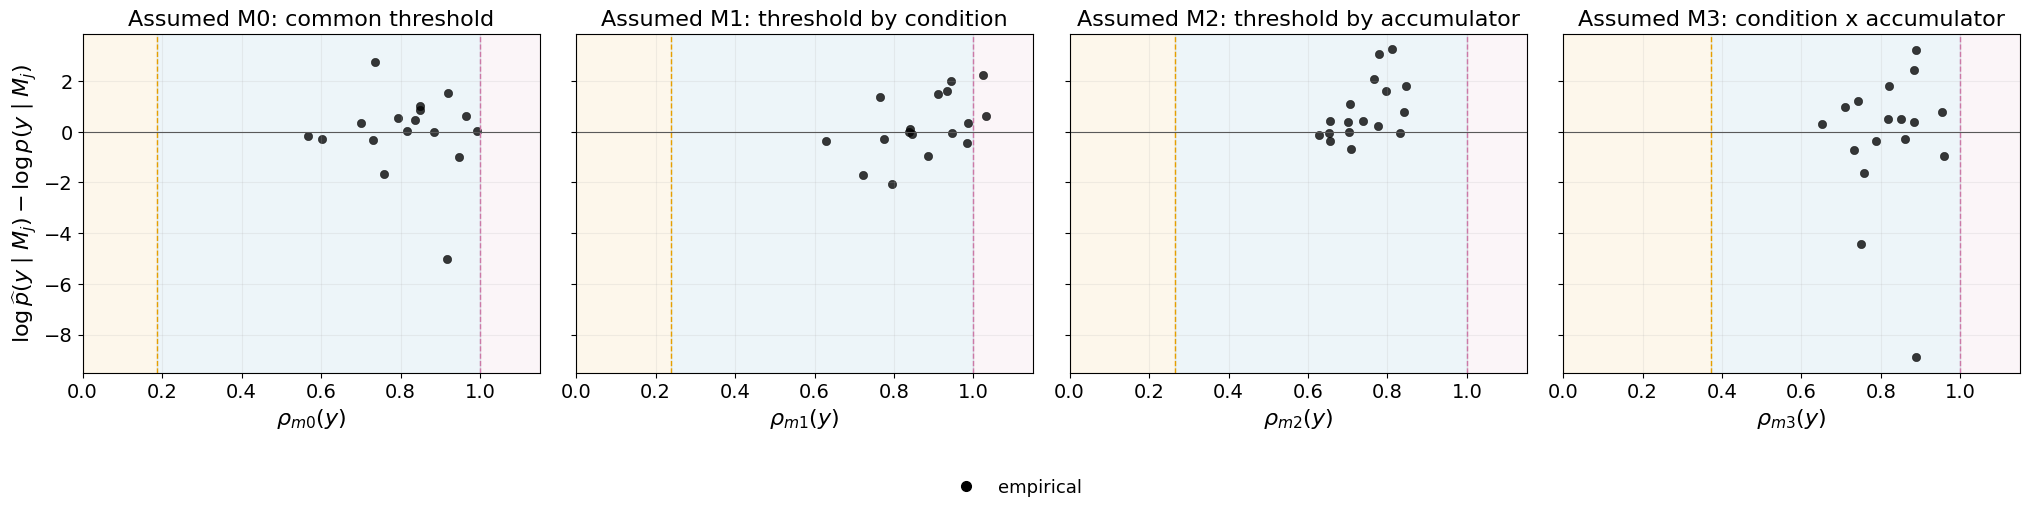

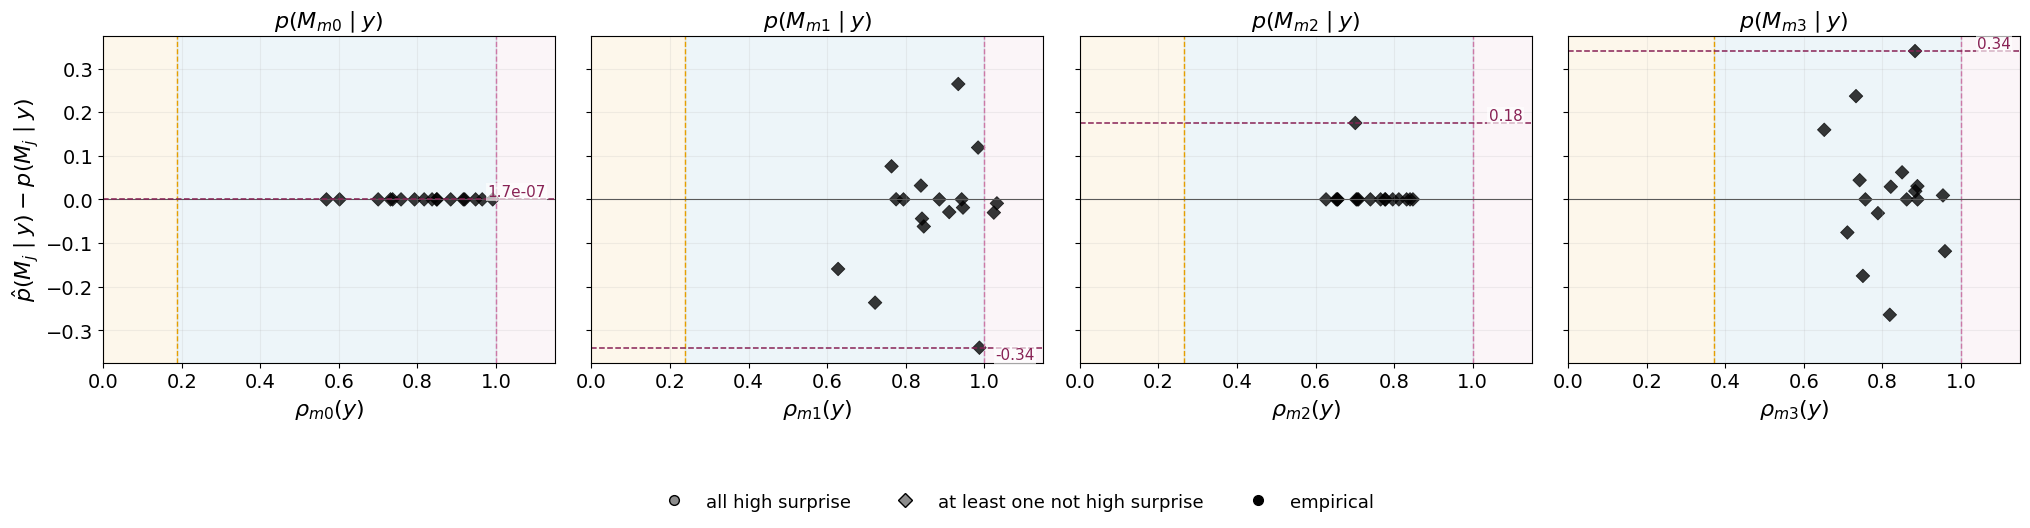

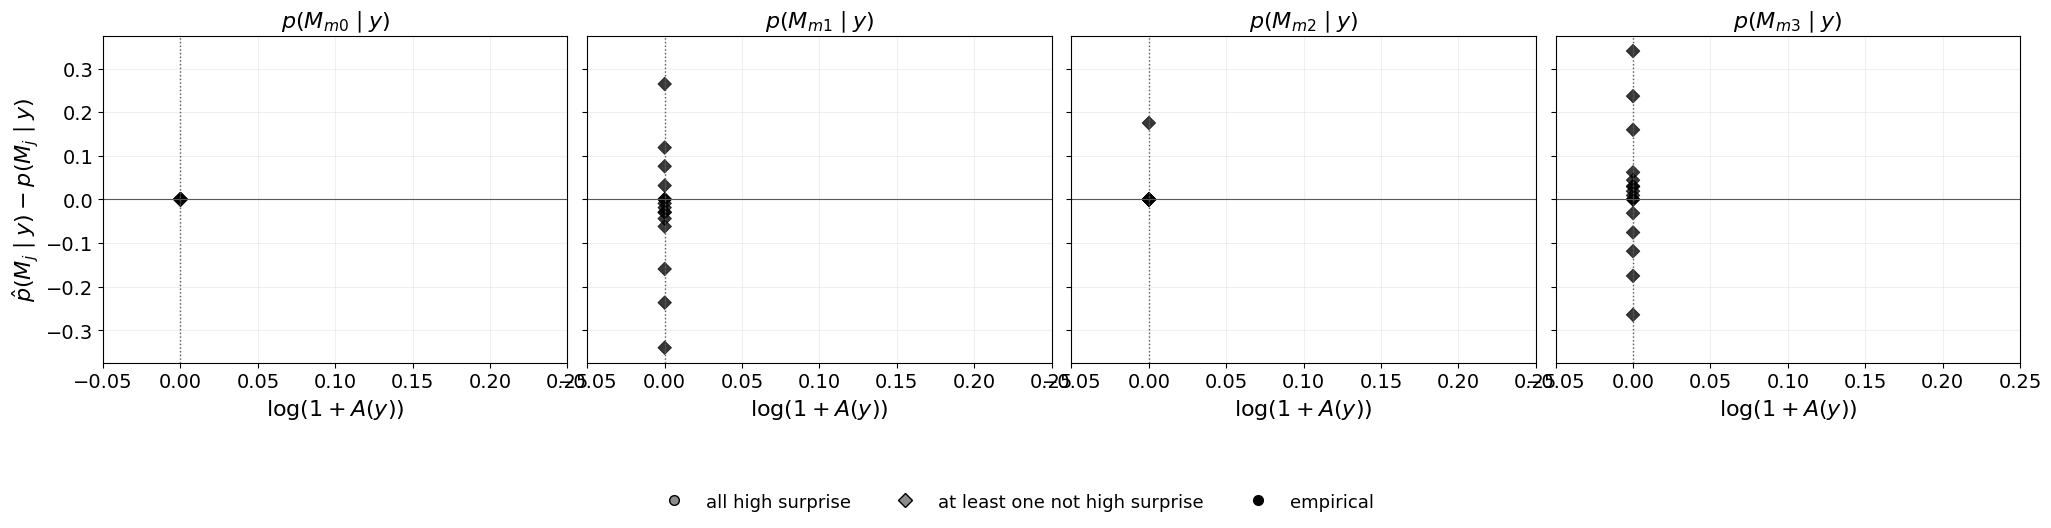

In [16]:
plot_logml_error_vs_rho(diagnostic, filename=f"npe_logml_error_vs_rho_{summary_tag}.png");
plot_pmp_error_vs_rho(diagnostic, filename=f"npe_pmp_error_vs_rho_{summary_tag}.png");
plot_pmp_error_vs_log_ambiguity(diagnostic, filename=f"npe_pmp_error_vs_log_ambiguity_{summary_tag}.png");


## 8. PMP Estimates vs Distance

Compare the NPE posterior model probability estimate with the Stan gold-standard PMP over summary distance.

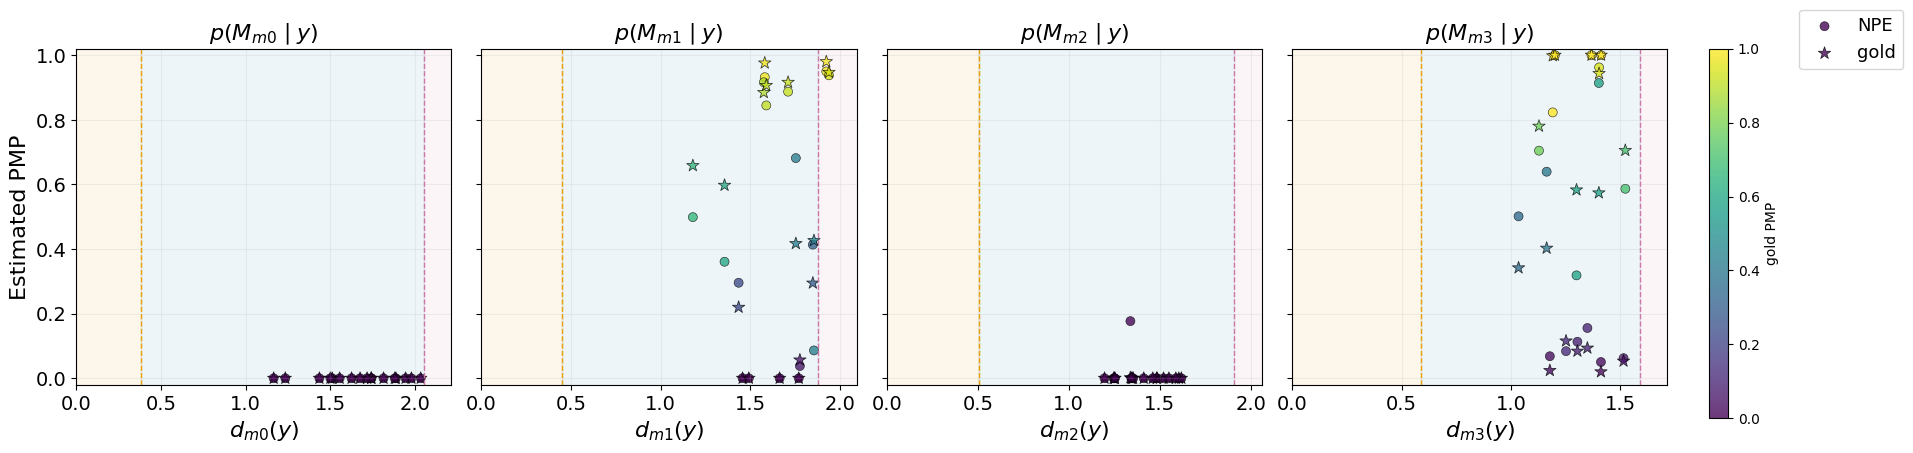

In [17]:
fig_pmp_estimates_distance, axes_pmp_estimates_distance = plot_pmp_estimates_vs_distance(
    diagnostic,
    x="distance",
    y="estimate",
    filename=f"npe_pmp_estimates_vs_distance_{summary_tag}.png",
)
